In [63]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from IPython.display import Image, display

from nn_helpers import MoogStokesNN
from mcmc import retrieve_spectrum_preproc
from mcmc_pipeline import (
    run_two_stage_source_raw,
    postprocess_two_stage_results,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [64]:
basename = "Spectrum_EPIC211095259.nspec"
data_path = "data/science/ClassIII-sources-spectra"

In [74]:
testdata, meta = retrieve_spectrum_preproc(
    basename,
    data_path=data_path,
    regions_override=[0, 1, 3, 4, 5, 6],
    return_metadata=True,
)

print(meta)

[Nyquist sampling] Factor applied: 1. Old SNR = 39.26549299820269
[Nyquist sampling] Factor applied: 1. New SNR = 39.26549299820269
{'basename': 'Spectrum_EPIC211095259.nspec', 'regions': [0, 1, 3, 4, 5, 6], 'n_regions': 6, 'shifts': array([ 9.491,  9.454,  9.47 ,  8.516, 11.494,  8.527,  8.49 ]), 'renormalization': array([1., 1., 1., 1., 1., 1., 1.]), 'masks': {}, 'nyquist_bin': 1, 'kernel': None, 'resolution': None, 'abs_path': '/Users/christianflores/Documents/GitHub/moogstokes-nn/data/science/ClassIII-sources-spectra/Spectrum_EPIC211095259.nspec'}


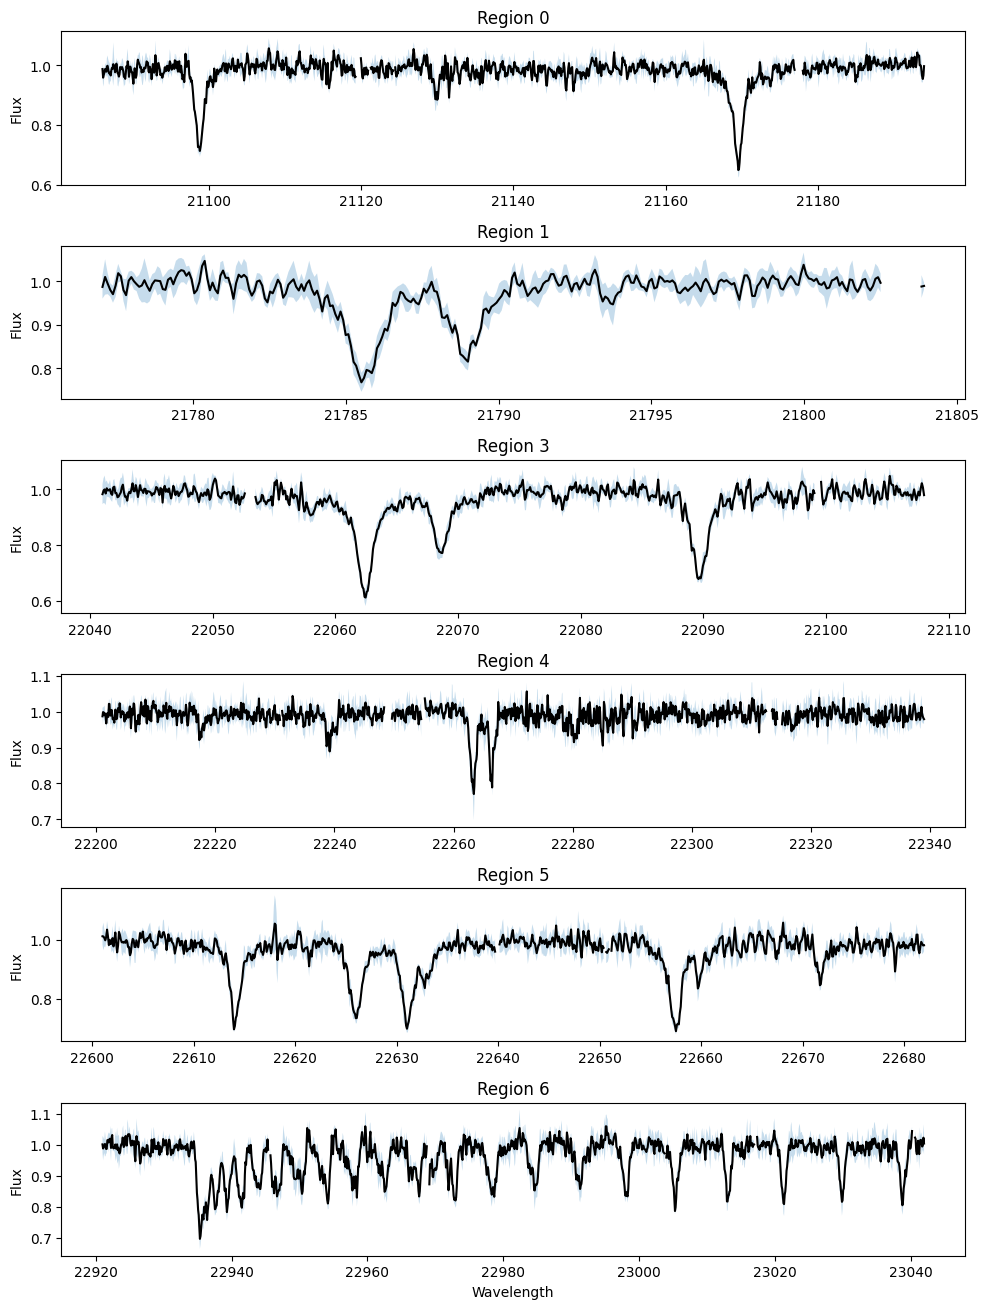

In [75]:
fig, axes = plt.subplots(len(testdata.regions), 1, figsize=(10, 2.2 * len(testdata.regions)))

if len(testdata.regions) == 1:
    axes = [axes]

for ax, r in zip(axes, testdata.regions):
    x, y, yerr = testdata.get_region(r)
    ax.plot(x, y, color="black")
    ax.fill_between(x, y - yerr, y + yerr, alpha=0.25)
    ax.set_title(f"Region {r}")
    ax.set_ylabel("Flux")

axes[-1].set_xlabel("Wavelength")
plt.tight_layout()
plt.show()

In [76]:
moognn = MoogStokesNN(nn_models_dir="data/", regions=range(7))

In [77]:
raw_test = run_two_stage_source_raw(
    basename=basename,
    moognn=moognn,
    data_path=data_path,
    nwalkers=16,
    nsteps=100,
    scale_discard=50,
    scale_thin=2,
    vsini_discard=80,
    vsini_thin=2,
    stage2_fixed_vsini=None,
)

[Nyquist sampling] Factor applied: 1. Old SNR = 39.26549299820269
[Nyquist sampling] Factor applied: 1. New SNR = 39.26549299820269


100%|██████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:15<00:00,  6.45it/s]


[yerr rescaled] Factor applied: 1.224912182950839. Total scaling so far: 1.224912182950839


100%|██████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.20it/s]


[Nyquist sampling] Factor applied: 1. Old SNR = 39.26549299820269
[Nyquist sampling] Factor applied: 1. New SNR = 39.26549299820269


100%|██████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:12<00:00,  7.85it/s]


[yerr rescaled] Factor applied: 1.0526551073387969. Total scaling so far: 1.0526551073387969


100%|██████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:12<00:00,  8.09it/s]


In [79]:
out_test = postprocess_two_stage_results(
    raw_test,
    moognn=moognn,
    data_path=data_path,
    discard=150,
    thin=2,
)
display(Image(out_test["stage1"]["trace_plot"]))
display(Image(out_test["stage2"]["trace_plot"]))


IndexError: index -1 is out of bounds for axis 0 with size 0

In [ ]:
display(Image(out_test["stage1"]["corner_plot"]))
display(Image(out_test["stage1"]["bestfit_plot"]))
display(Image(out_test["stage1"]["residual_plot"]))

display(Image(out_test["stage2"]["corner_plot"]))
display(Image(out_test["stage2"]["bestfit_plot"]))
display(Image(out_test["stage2"]["residual_plot"]))


In [71]:
raw = run_two_stage_source_raw(
    basename=basename,
    moognn=moognn,
    data_path=data_path,
    nwalkers=16,
    nsteps=1000,
    scale_discard=400,
    scale_thin=5,
    vsini_discard=800,
    vsini_thin=5,
    stage2_fixed_vsini=None,
)

[Nyquist sampling] Factor applied: 1. Old SNR = 39.26549299820269
[Nyquist sampling] Factor applied: 1. New SNR = 39.26549299820269


100%|████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:53<00:00,  5.77it/s]


[yerr rescaled] Factor applied: 1.063913688293681. Total scaling so far: 1.063913688293681


100%|████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [03:13<00:00,  5.16it/s]


[Nyquist sampling] Factor applied: 1. Old SNR = 39.26549299820269
[Nyquist sampling] Factor applied: 1. New SNR = 39.26549299820269


100%|████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:32<00:00,  6.55it/s]


[yerr rescaled] Factor applied: 1.0399486657825785. Total scaling so far: 1.0399486657825785


100%|████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:32<00:00,  6.54it/s]


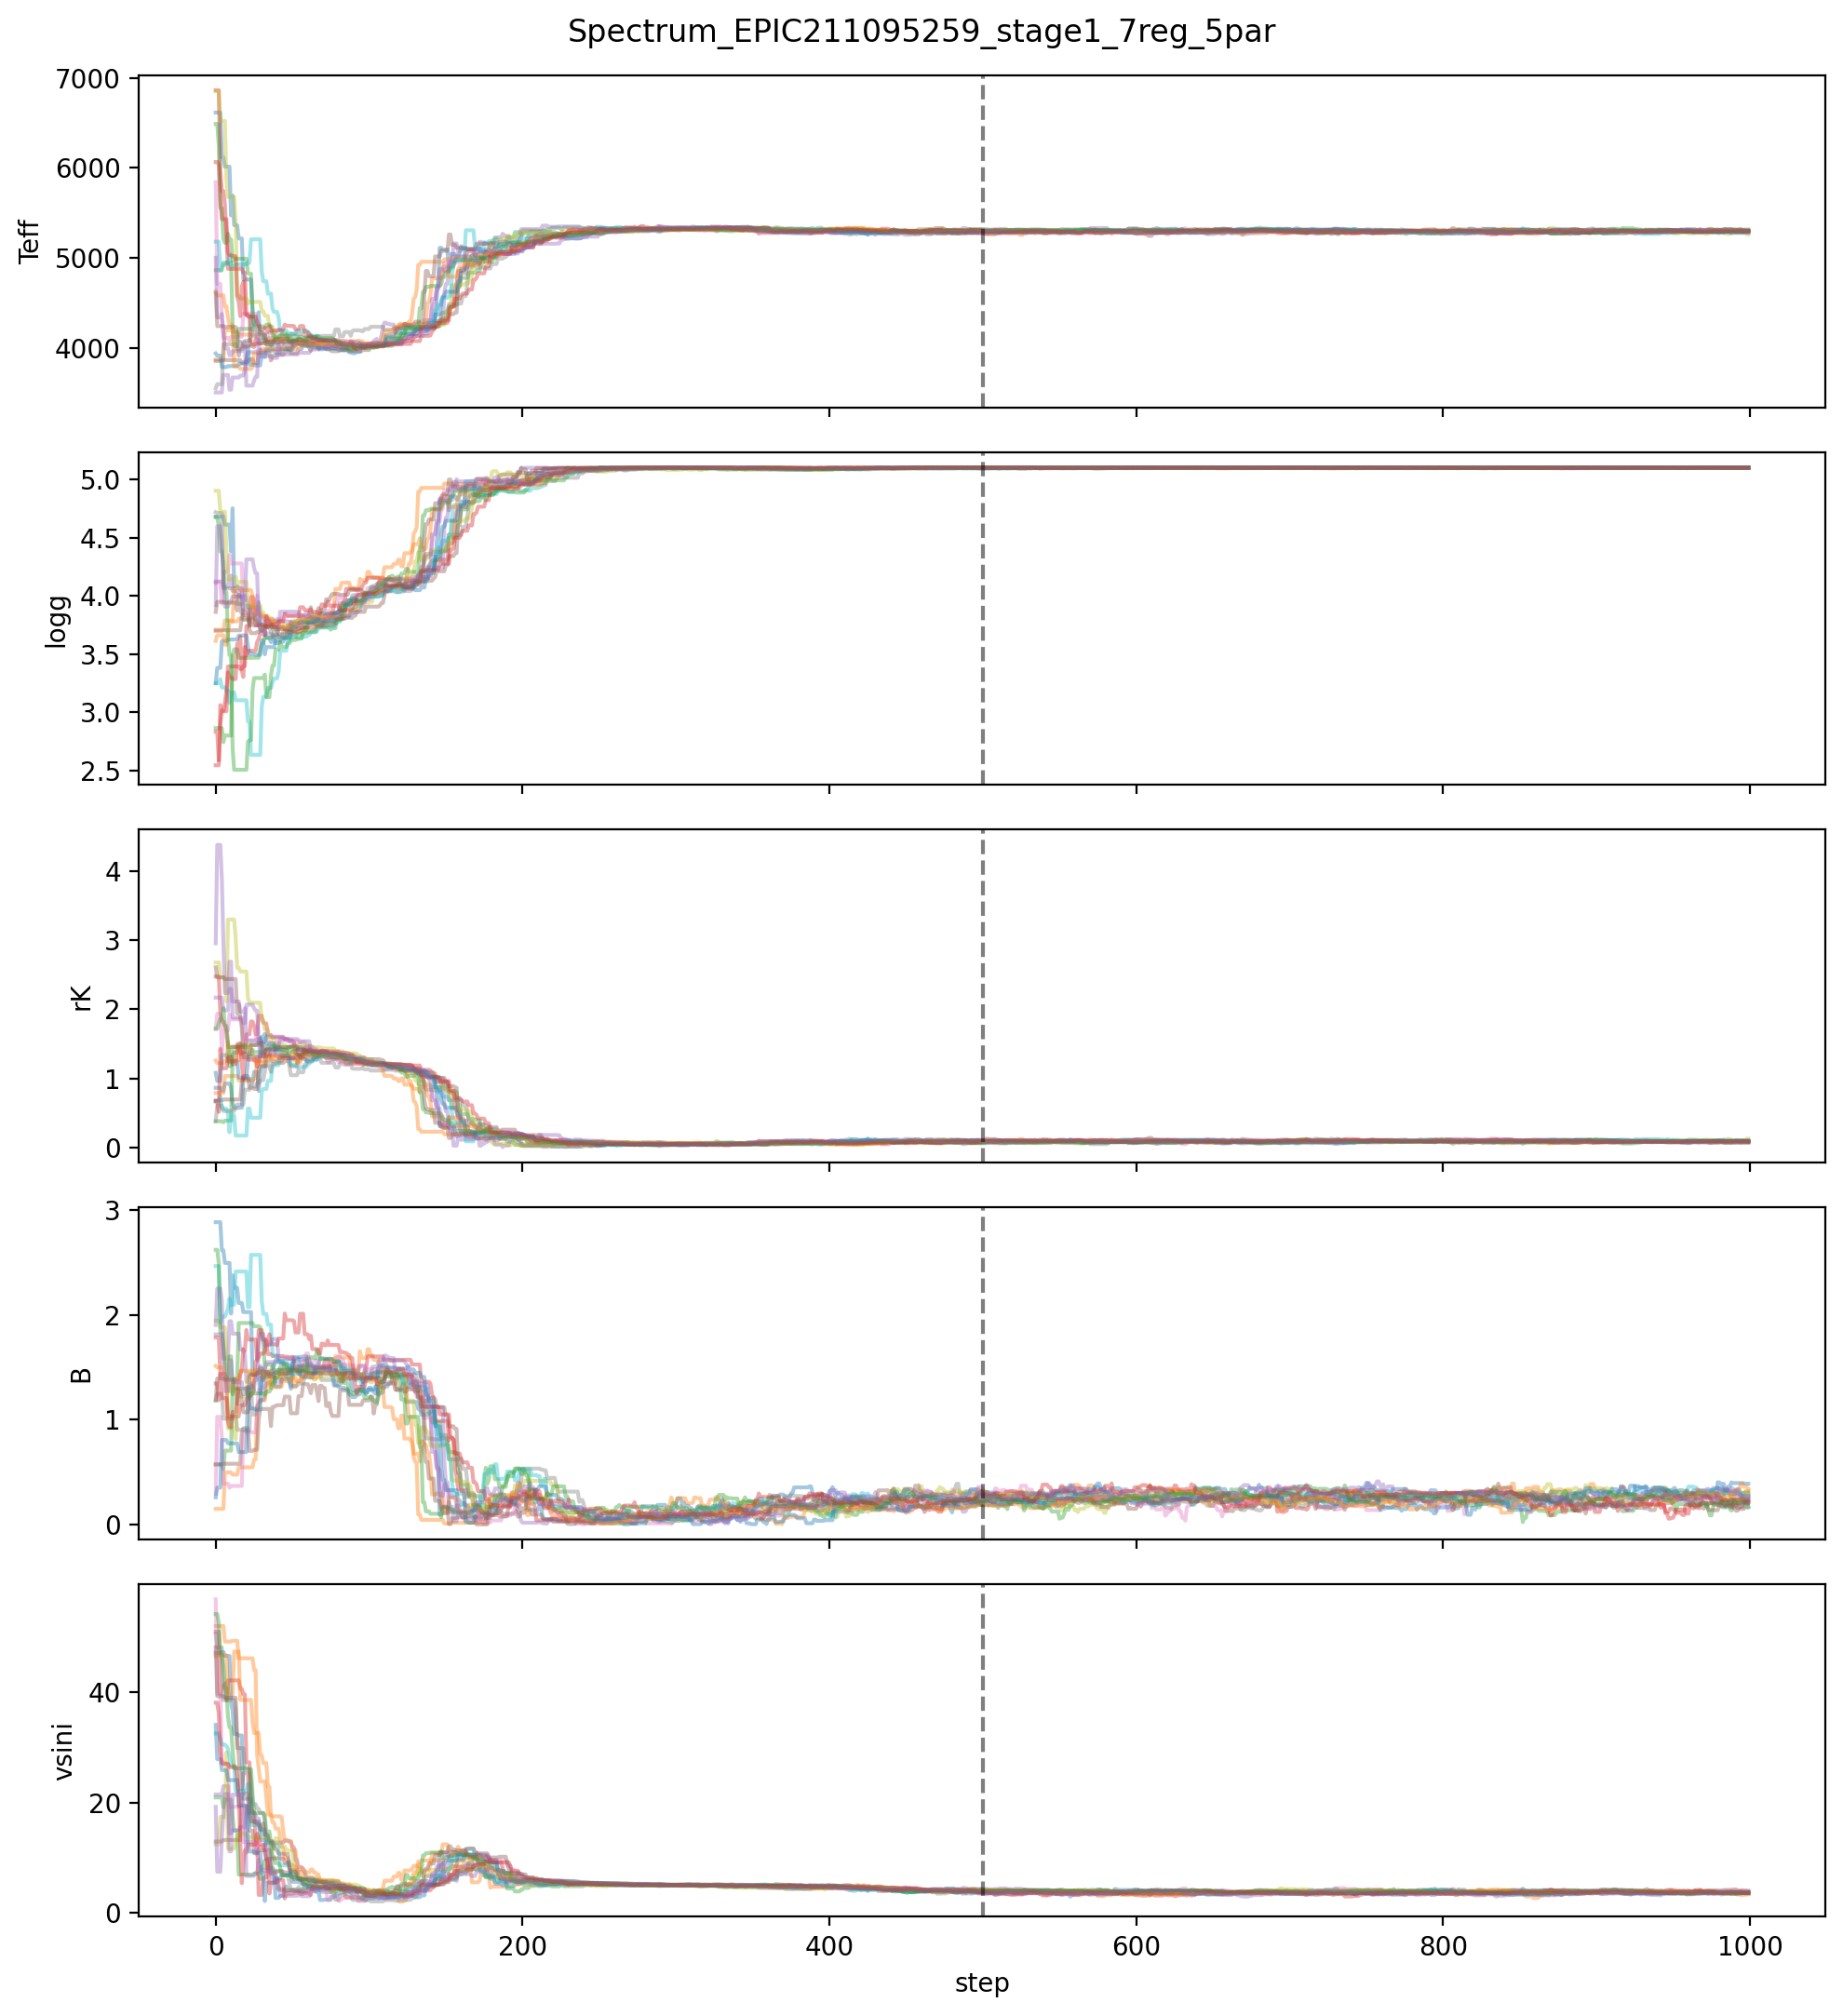

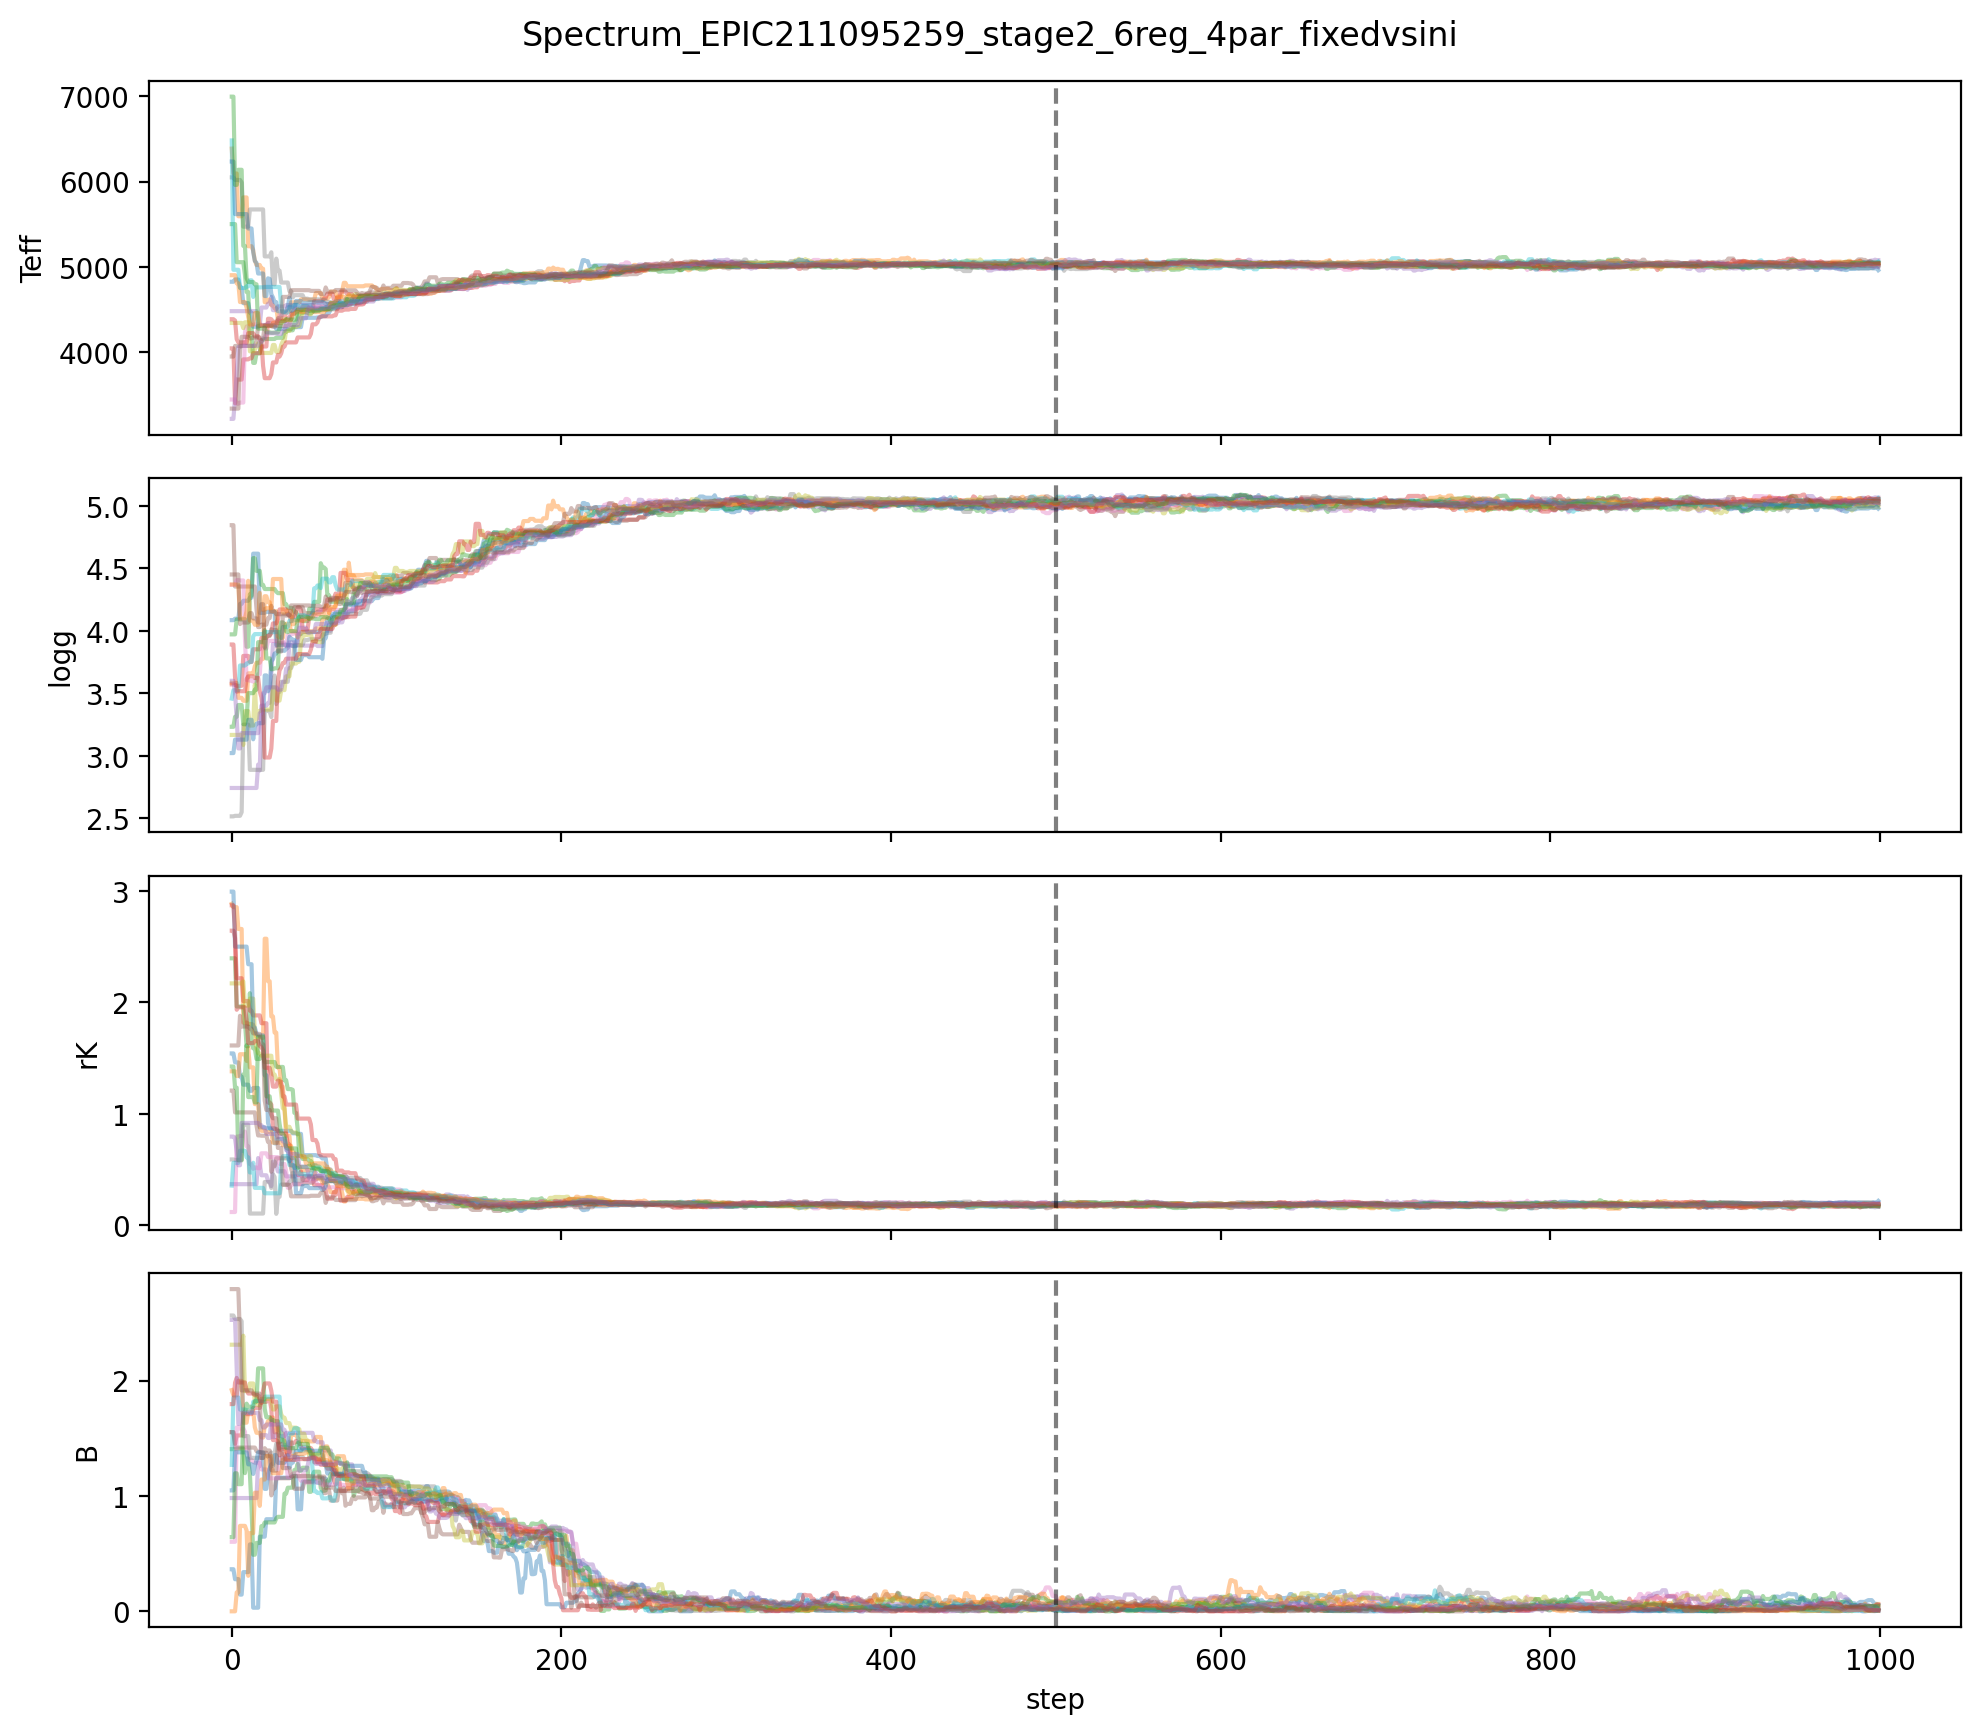

In [72]:
out = postprocess_two_stage_results(
    raw,
    moognn=moognn,
    data_path=data_path,
    discard=500,
    thin=5,
)

display(Image(out["stage1"]["trace_plot"]))
display(Image(out["stage2"]["trace_plot"]))

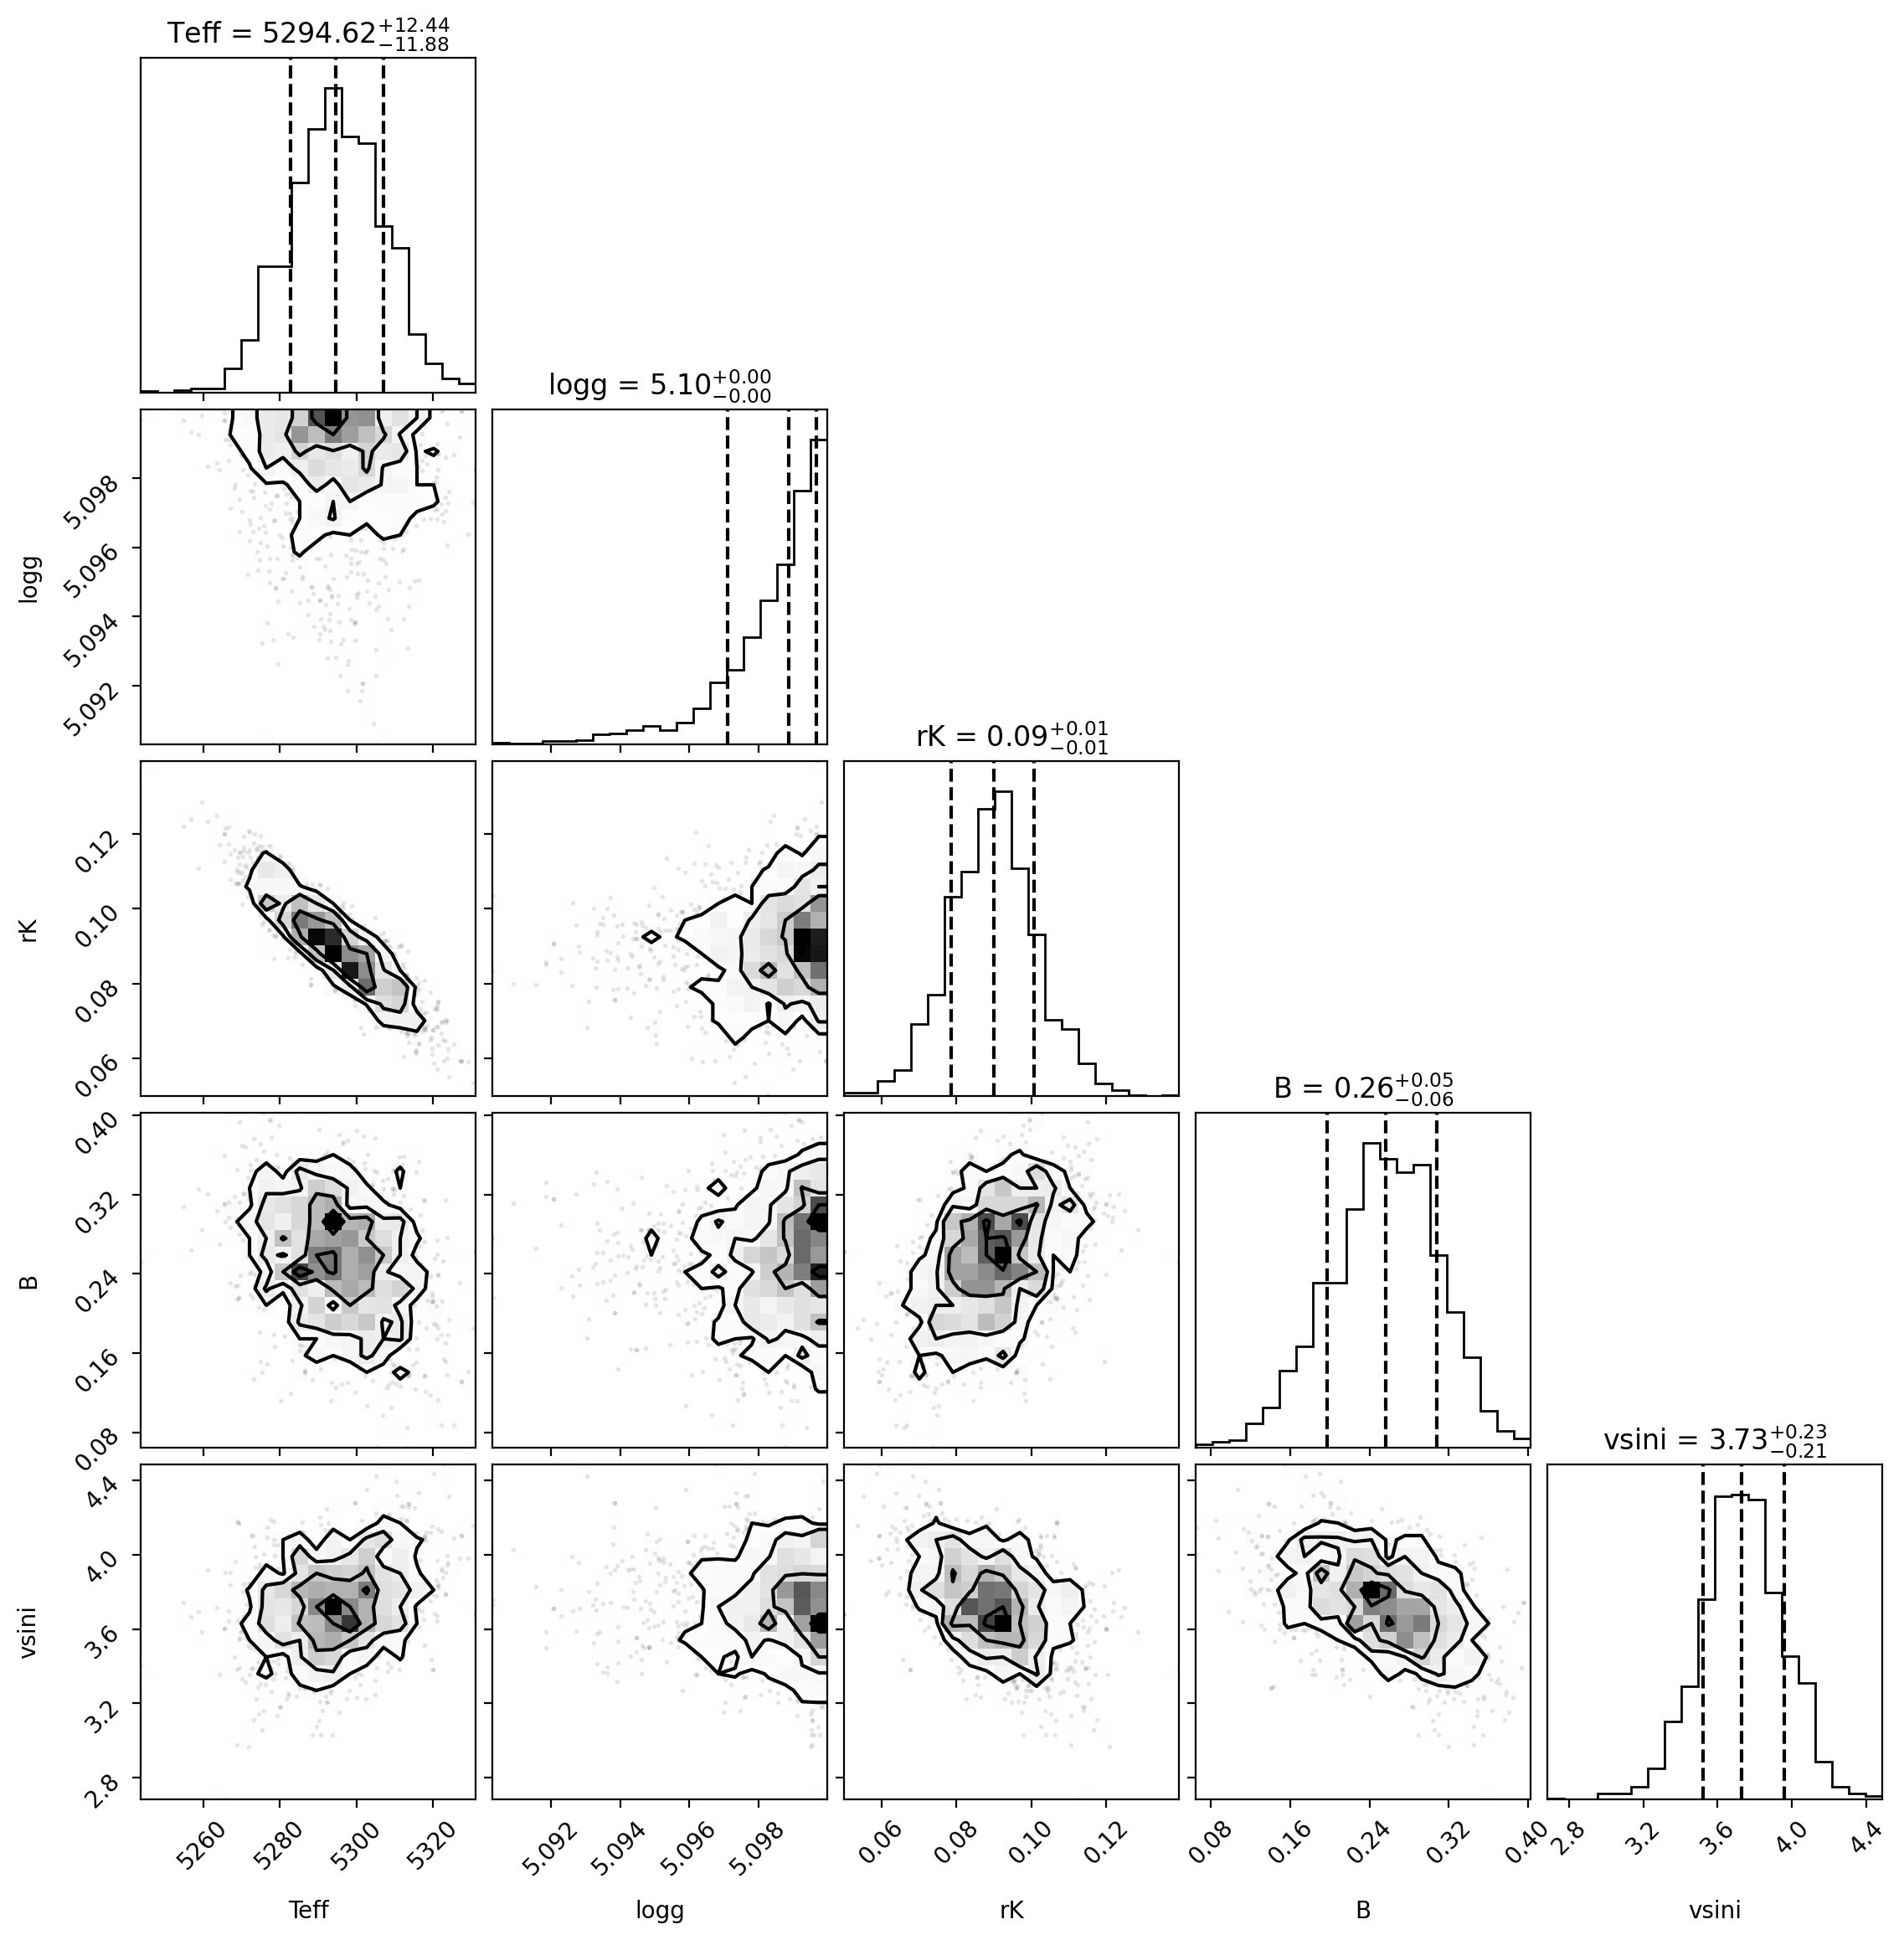

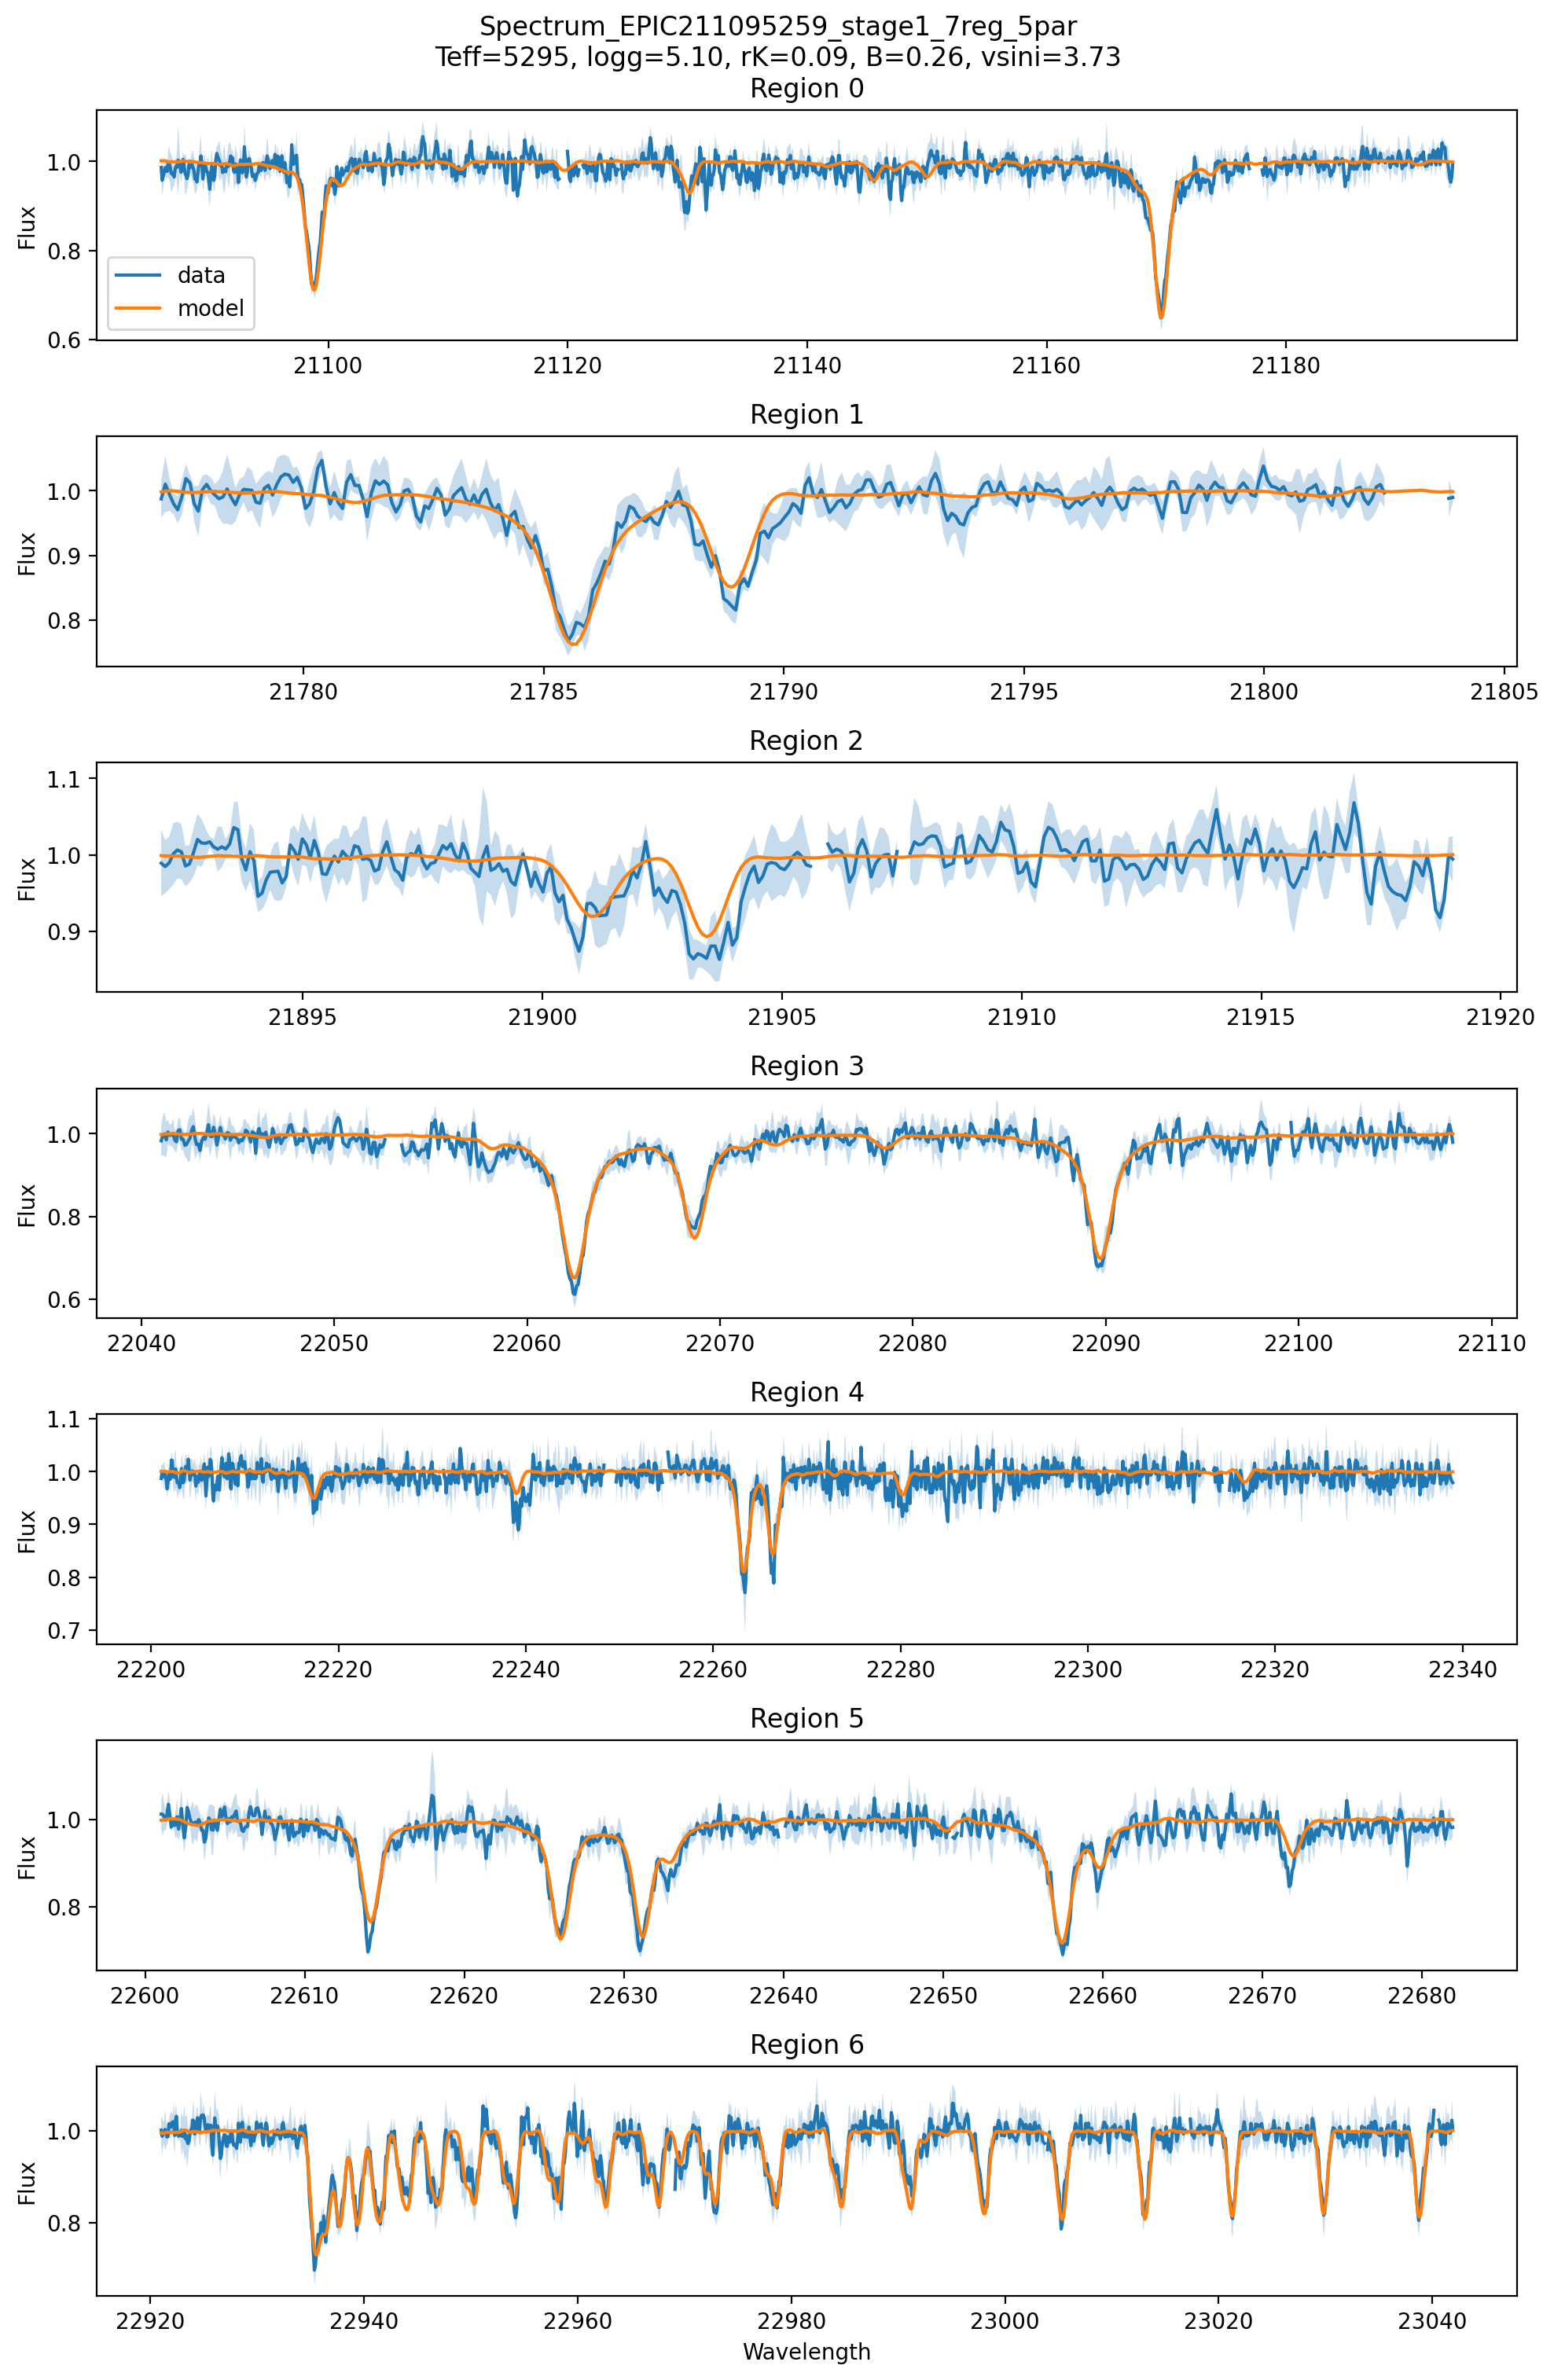

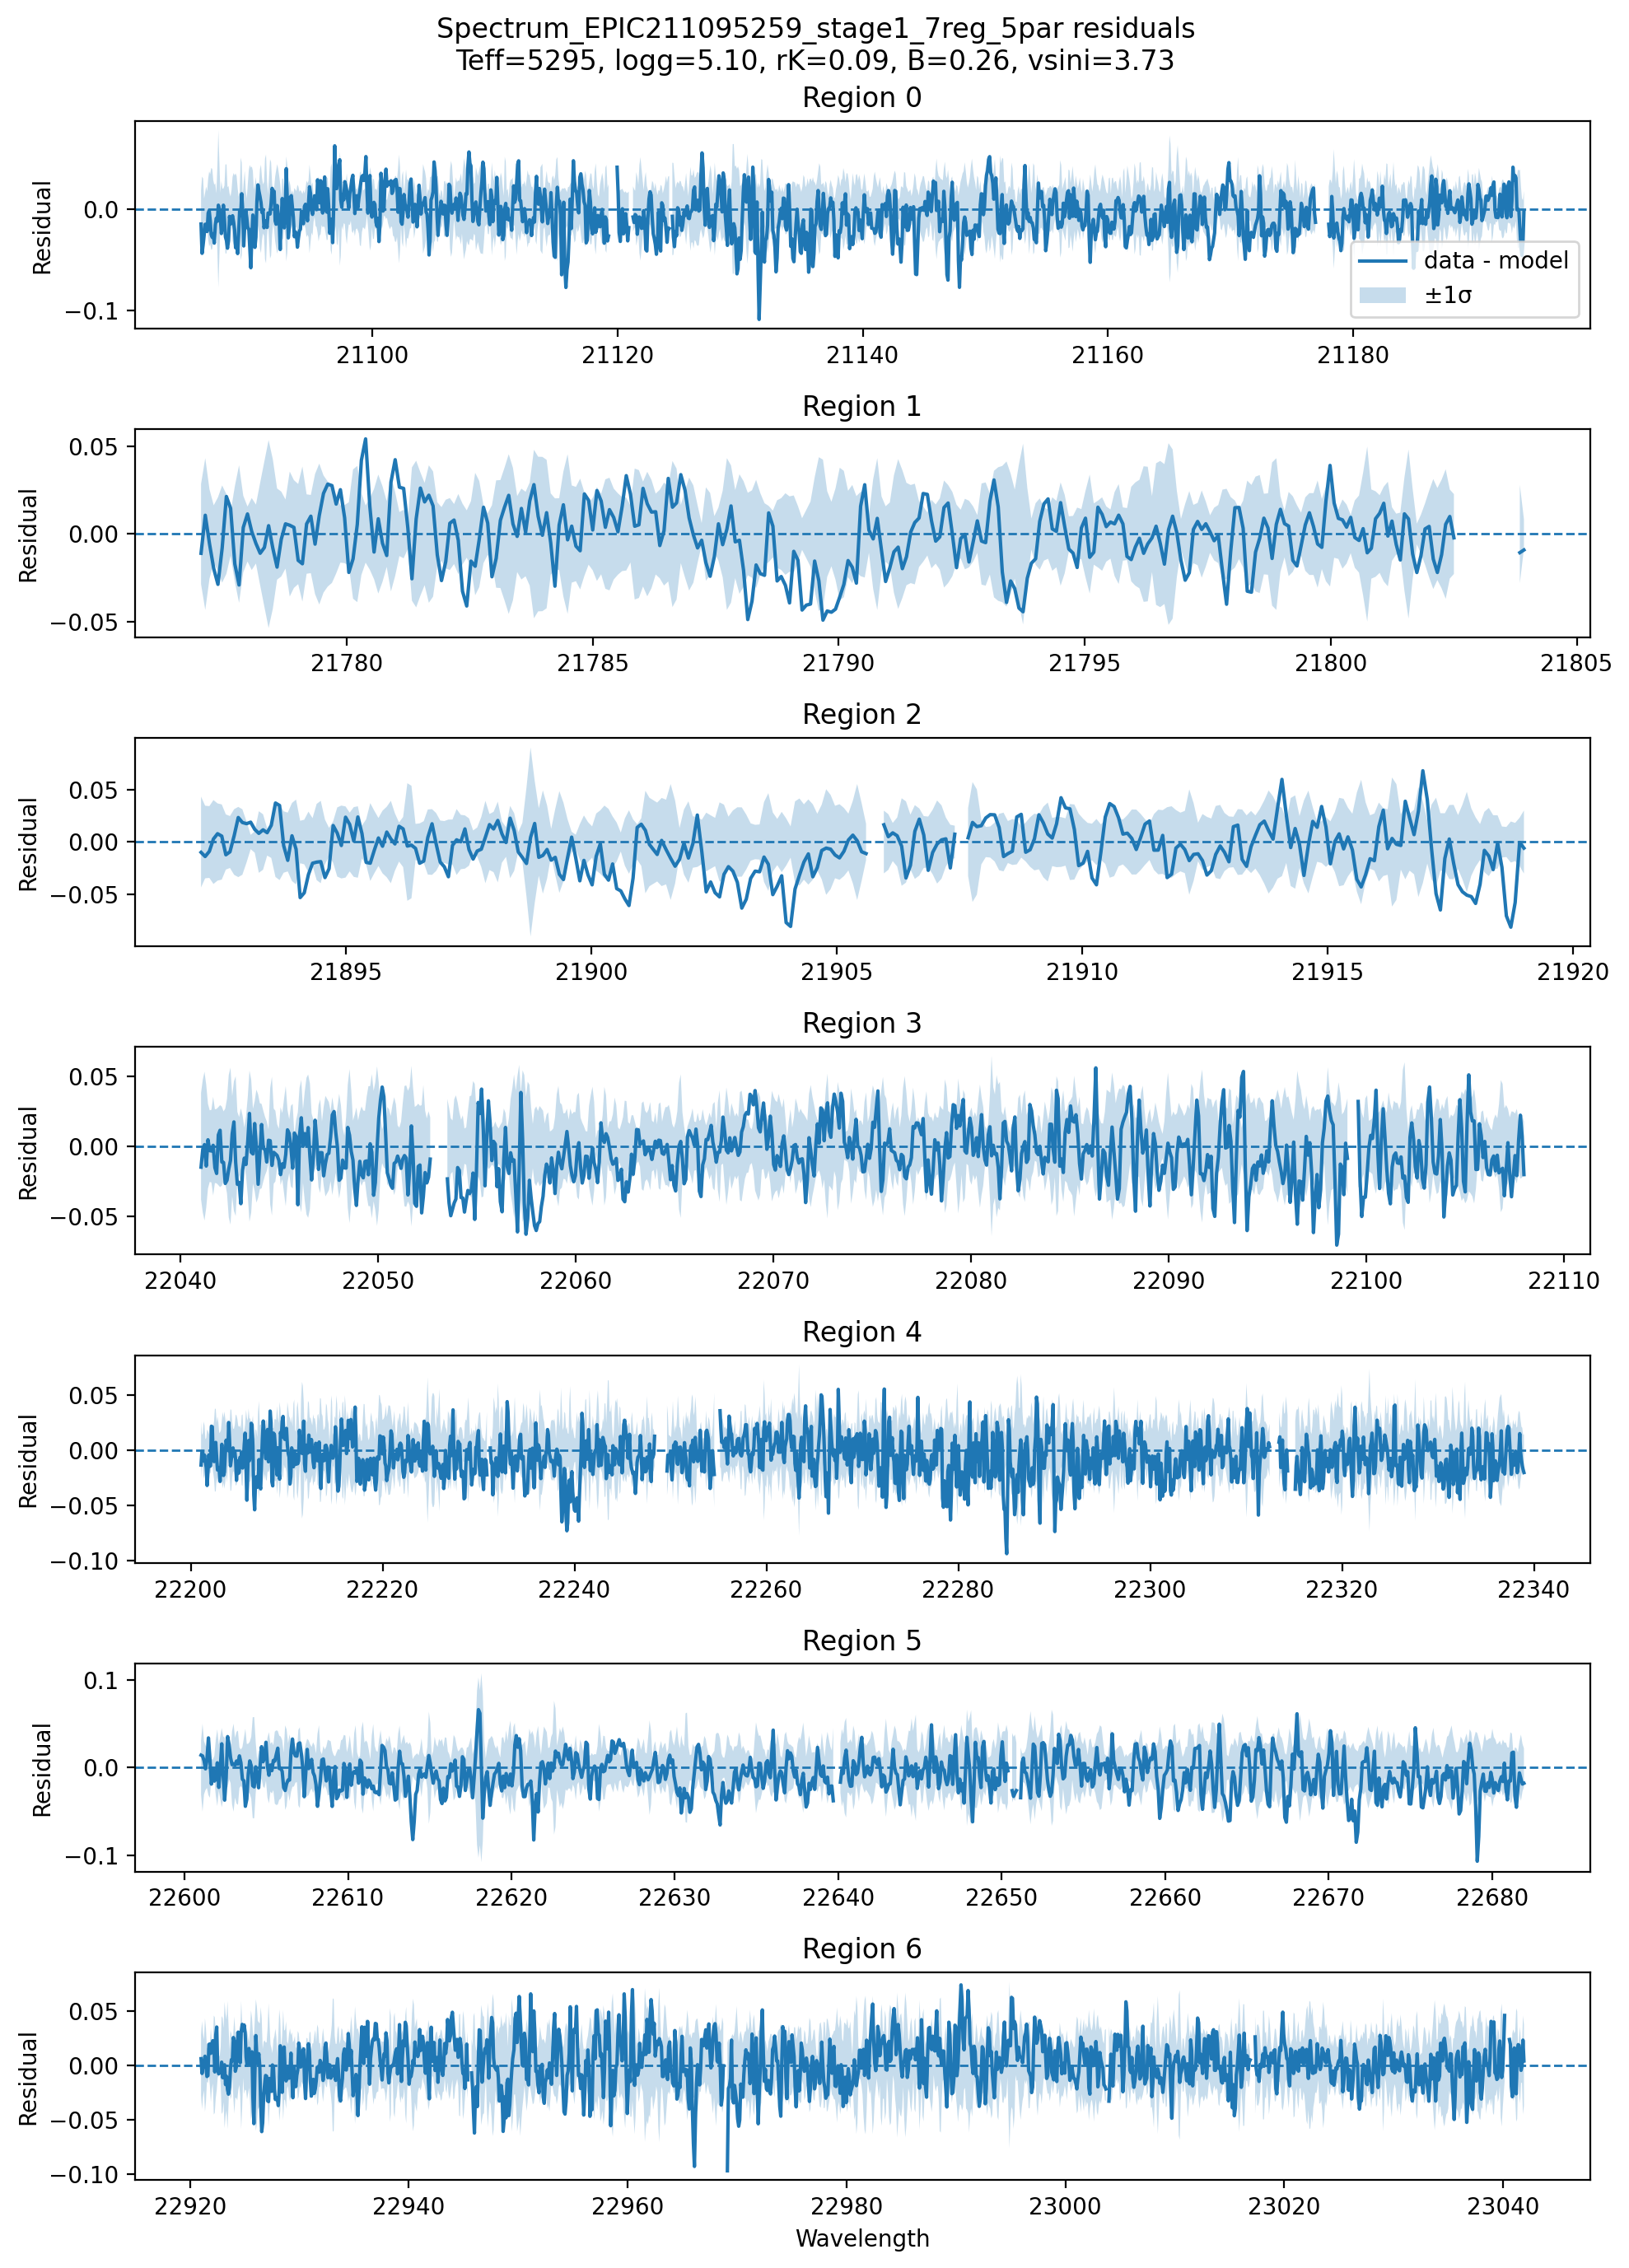

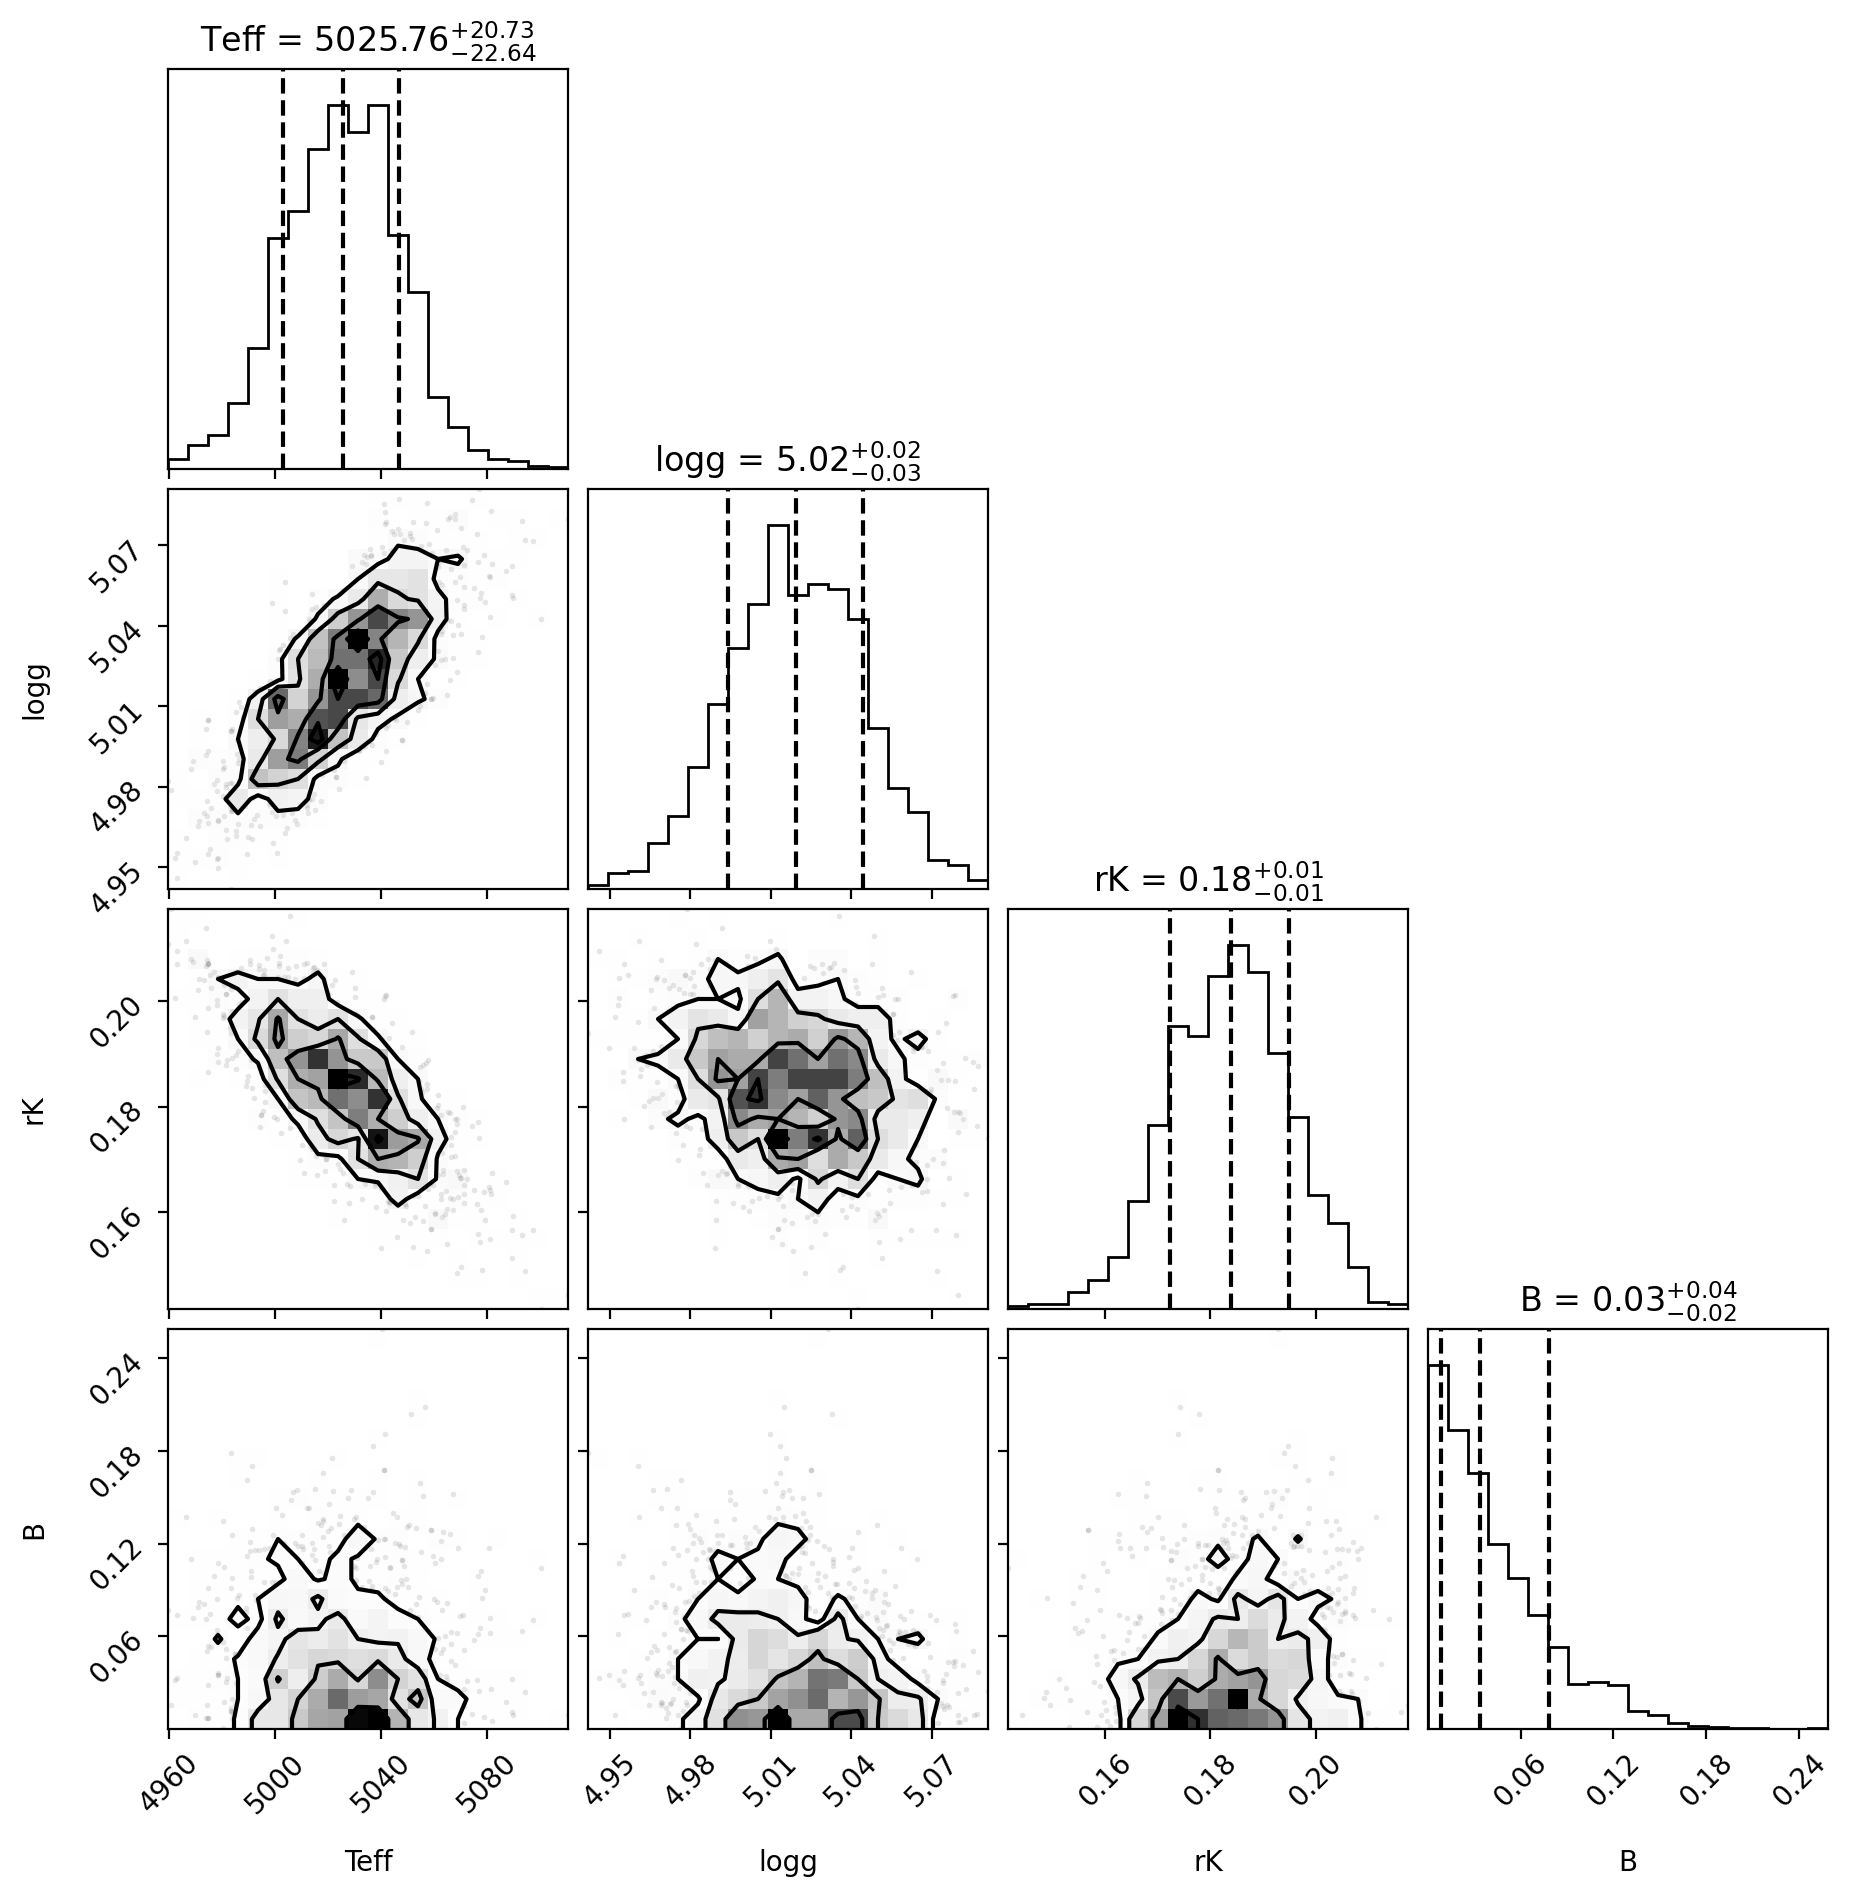

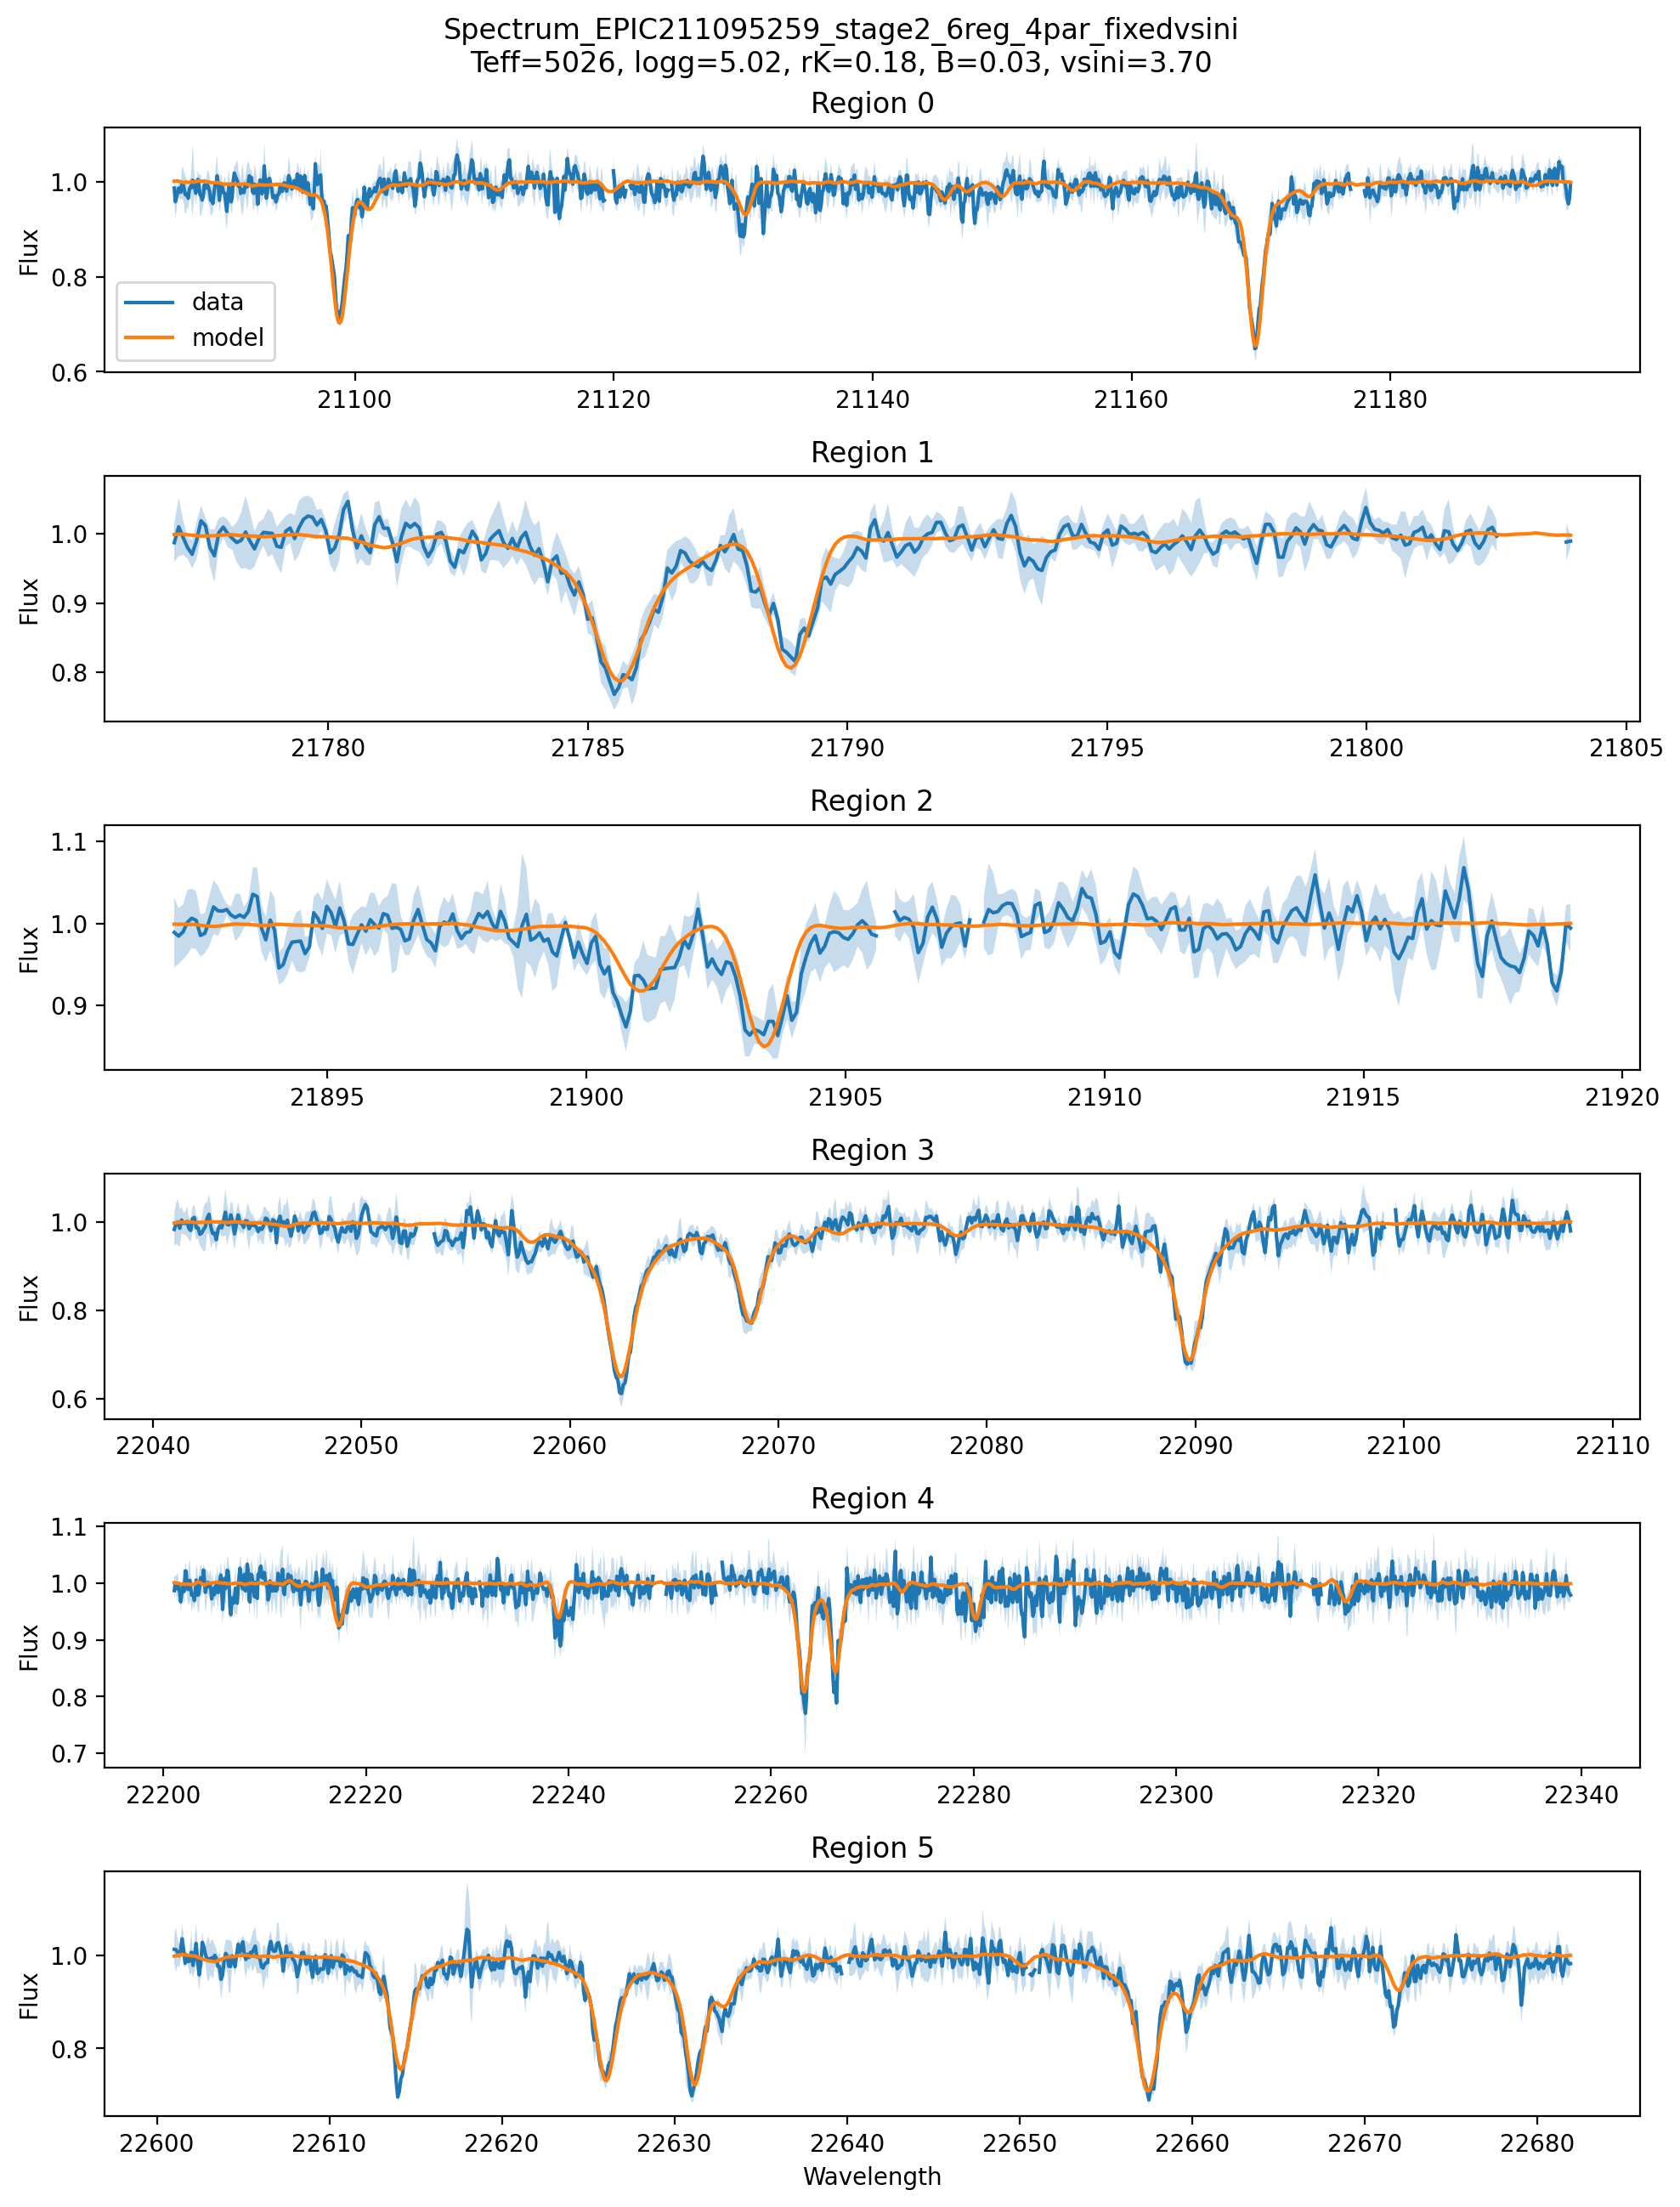

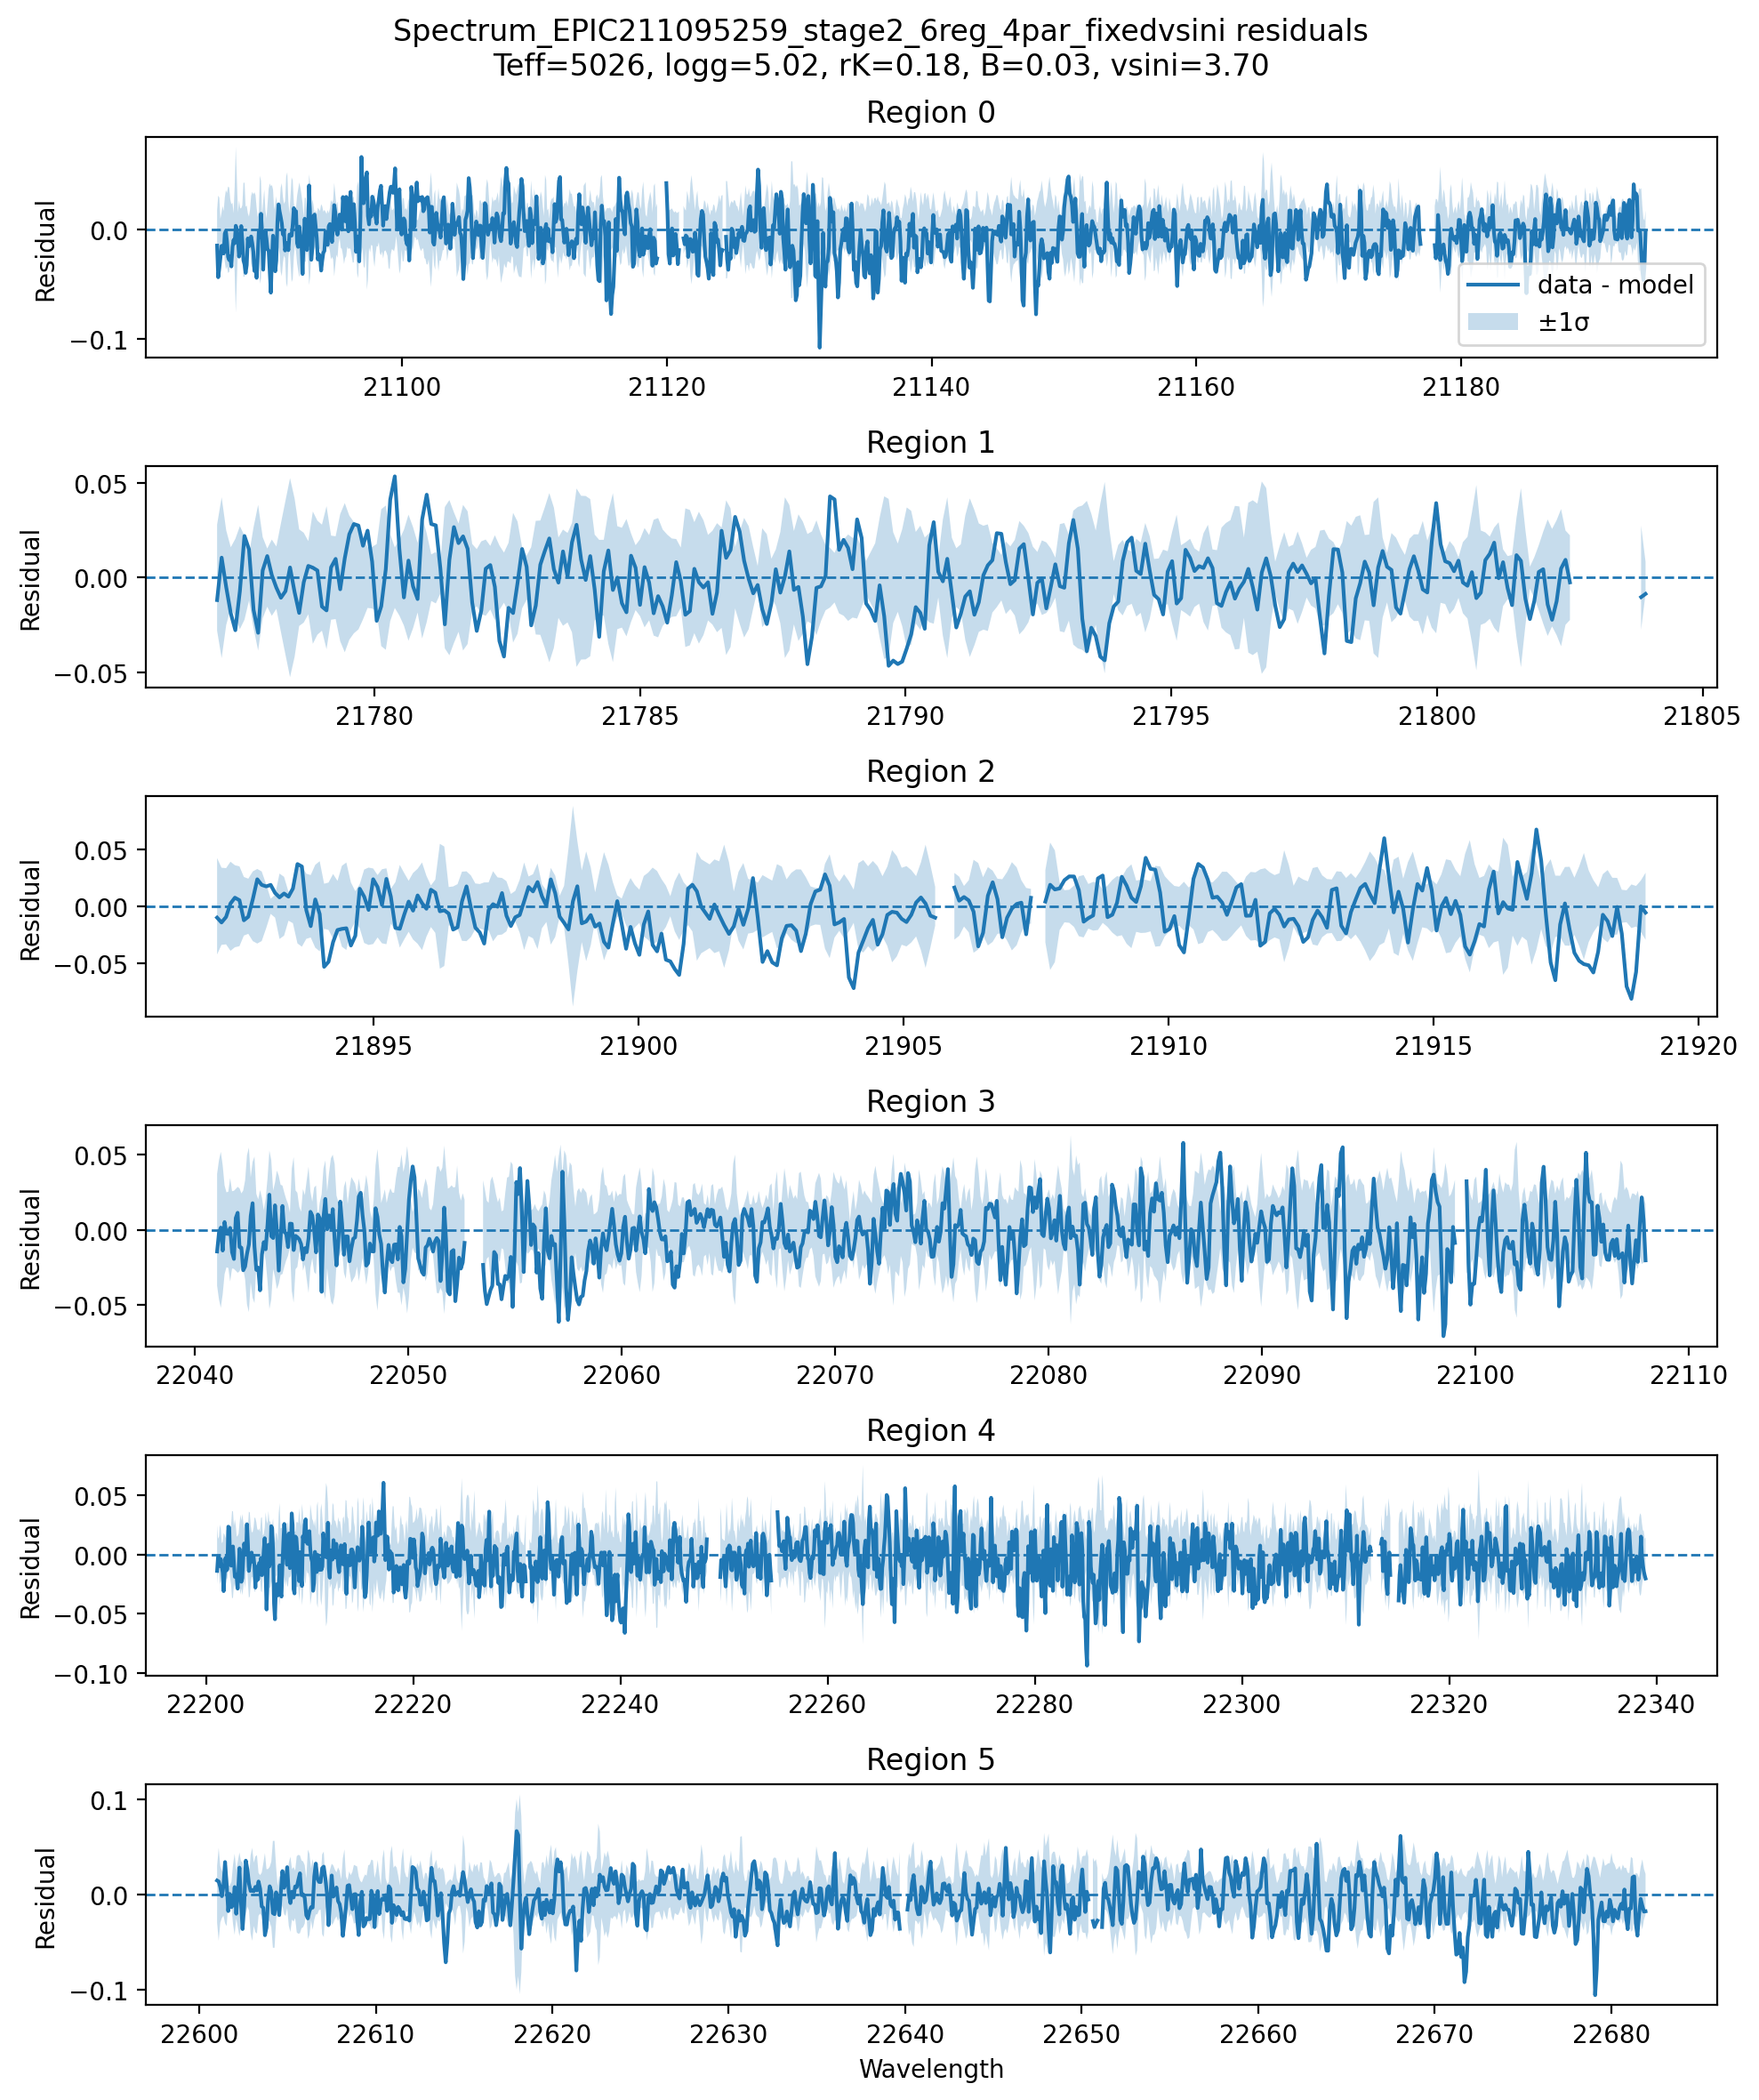

In [73]:
display(Image(out["stage1"]["corner_plot"]))
display(Image(out["stage1"]["bestfit_plot"]))
display(Image(out["stage1"]["residual_plot"]))

display(Image(out["stage2"]["corner_plot"]))
display(Image(out["stage2"]["bestfit_plot"]))
display(Image(out["stage2"]["residual_plot"]))
